# Preprocessing and Augmentation Visualizer

This notebook imports the real pairwise preprocessing pipeline from `data.py` and visualizes what happens to a left/right comparison pair before it reaches the model. It is intended for thesis figures: raw pair, deterministic validation preprocessing, repeated training augmentations, and the sampled augmentation decisions.

In [1]:
from pathlib import Path
import copy
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

ROOT = Path.cwd().resolve()
if ROOT.name == "Analysis":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from data import ComparisonsDataset, build_preprocessing_transforms

print("Project root:", ROOT)

Project root: /home/csantiago


/home/csantiago/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

Edit these values to match the run you want to describe in the report. The default specs mirror the common 224x224 ViT/CNN preprocessing shape used in the training code.

In [2]:
COMPARISONS_PATH = ROOT / "comparisons_df.pickle"
IMAGE_ROOT = ROOT / "images"
GAZE_ROOT = ROOT / "Eyetracker_attention_maps"

AUGMENT_LEVEL = "heavy"  # "none", "light", or "heavy"
USE_GAZE = GAZE_ROOT.exists()
GAZE_OUTPUT = "align"
GAZE_GRID_SIZE = (14, 14)

MODEL_SPECS = {
    "input_size": (3, 224, 224),
    "crop_pct": 0.875,
    "interpolation": "bicubic",
    "mean": (0.485, 0.456, 0.406),
    "std": (0.229, 0.224, 0.225),
}

print("comparisons:", COMPARISONS_PATH)
print("image root:", IMAGE_ROOT)
print("gaze enabled:", USE_GAZE)

comparisons: /home/csantiago/comparisons_df.pickle
image root: /home/csantiago/images
gaze enabled: False


## Load One Real Pair

The notebook uses the same `ComparisonsDataset` class as training. If gaze files are available, it prefers an eyetracker row; otherwise it falls back to any valid image pair.

In [3]:
def load_comparisons(path: Path) -> pd.DataFrame:
    try:
        df = pd.read_pickle(path)
    except Exception:
        import pickle
        with open(path, "rb") as f:
            df = pickle.load(f)

    df = df.copy()
    for side in ("image_l", "image_r"):
        df[side] = df[side].astype(str).apply(lambda x: x if x.lower().endswith(".jpg") else f"{x}.jpg")
    if "score_classification" not in df.columns:
        if (df["score"] == 0).any():
            df["score_classification"] = df["score"] + 1
        else:
            df["score_classification"] = df["score"].replace({-1: 0, 1: 1})
    return df


def image_path_for_row(row: pd.Series, side: str) -> Path:
    fname = row[f"image_{side}"]
    if "dataset" in row.index and pd.notna(row["dataset"]):
        return IMAGE_ROOT / str(row["dataset"]) / str(fname)
    return IMAGE_ROOT / str(fname)


df = load_comparisons(COMPARISONS_PATH)
valid = df[df.apply(lambda r: image_path_for_row(r, "l").exists() and image_path_for_row(r, "r").exists(), axis=1)].copy()

if USE_GAZE and "has_eyetracker" in valid.columns:
    eye_valid = valid[valid["has_eyetracker"].fillna(False).astype(bool)]
    if len(eye_valid) > 0:
        valid = eye_valid

if len(valid) == 0:
    raise RuntimeError("No valid image pairs found. Check COMPARISONS_PATH and IMAGE_ROOT.")

row = valid.iloc[0]
one_row = pd.DataFrame([row])

raw_dataset = ComparisonsDataset(
    one_row,
    root_dir=str(IMAGE_ROOT),
    transform=None,
    gaze_root=str(GAZE_ROOT) if USE_GAZE else None,
    use_gaze=USE_GAZE,
)
raw_sample = raw_dataset[0]

print("Left:", raw_sample["image_l_name"])
print("Right:", raw_sample["image_r_name"])
print("score_r:", raw_sample["score_r"], "score_c:", raw_sample["score_c"])
print("has gaze:", raw_sample.get("has_eyetracker", False))

Left: /home/csantiago/images/berlin/3676.jpg
Right: /home/csantiago/images/berlin/10046.jpg
score_r: -1 score_c: 0
has gaze: False


## Build The Same Pipelines Used In Training

In [4]:
eval_transform, eval_meta = build_preprocessing_transforms(
    MODEL_SPECS,
    phase="eval",
    augment="none",
    ties=True,
    gaze_grid_size=GAZE_GRID_SIZE,
    enable_gaze=USE_GAZE,
    gaze_output=GAZE_OUTPUT,
)

train_transform, train_meta = build_preprocessing_transforms(
    MODEL_SPECS,
    phase="train",
    augment=AUGMENT_LEVEL,
    ties=True,
    gaze_grid_size=GAZE_GRID_SIZE,
    enable_gaze=USE_GAZE,
    gaze_output=GAZE_OUTPUT,
)

display(pd.DataFrame([eval_meta, train_meta]))

,target_crop,resize_dim,crop_pct,interpolation,mean,std,gaze_grid_size,enable_gaze,gaze_output,phase,augment,policy,eval_policy,train_policy
0,224,256,0.875,bicubic,"(0.485, 0.456, 0.406)","(0.229, 0.224, 0.225)","(14, 14)",False,align,eval,none,"Resize(short,img) -> Crop(img); if enable_gaze...","Resize(short,img) -> Crop(img); if enable_gaze...",NaN
1,224,256,0.875,bicubic,"(0.485, 0.456, 0.406)","(0.229, 0.224, 0.225)","(14, 14)",False,align,train,heavy,"Resize(short,img) -> optional Swap/HFlip/Rotat...",NaN,"Resize(short,img) -> optional Swap/HFlip/Rotat..."


## Visualization Helpers

In [5]:
MEAN = torch.tensor(MODEL_SPECS["mean"]).view(3, 1, 1)
STD = torch.tensor(MODEL_SPECS["std"]).view(3, 1, 1)


def image_to_numpy(x):
    if torch.is_tensor(x):
        x = (x.detach().cpu() * STD + MEAN).clamp(0, 1)
        return x.permute(1, 2, 0).numpy()
    return np.asarray(x).astype(np.float32) / 255.0


def gaze_to_numpy(gaze, image_hw):
    if gaze is None or not torch.is_tensor(gaze):
        return None
    g = gaze.detach().float().cpu()
    if g.ndim == 3:
        g = g[0]
    if float(g.max()) <= 0:
        return None
    g = torch.nn.functional.interpolate(
        g[None, None], size=image_hw, mode="bilinear", align_corners=False
    )[0, 0]
    g = g - g.min()
    g = g / (g.max() + 1e-8)
    return g.numpy()


def show_pair(ax_l, ax_r, sample, title):
    img_l = image_to_numpy(sample["image_l"])
    img_r = image_to_numpy(sample["image_r"])
    ax_l.imshow(img_l)
    ax_r.imshow(img_r)

    gaze_l = gaze_to_numpy(sample.get("gaze_l"), img_l.shape[:2])
    gaze_r = gaze_to_numpy(sample.get("gaze_r"), img_r.shape[:2])
    if gaze_l is not None:
        ax_l.imshow(gaze_l, cmap="magma", alpha=0.35)
    if gaze_r is not None:
        ax_r.imshow(gaze_r, cmap="magma", alpha=0.35)

    ax_l.set_title(f"{title} - left")
    ax_r.set_title(f"{title} - right")
    ax_l.axis("off")
    ax_r.axis("off")


def transform_with_seed(transform, sample, seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    out = transform(copy.deepcopy(sample))
    return out, copy.deepcopy(transform.last_trace)

## Raw Pair, Eval Preprocessing, And Training Augmentations

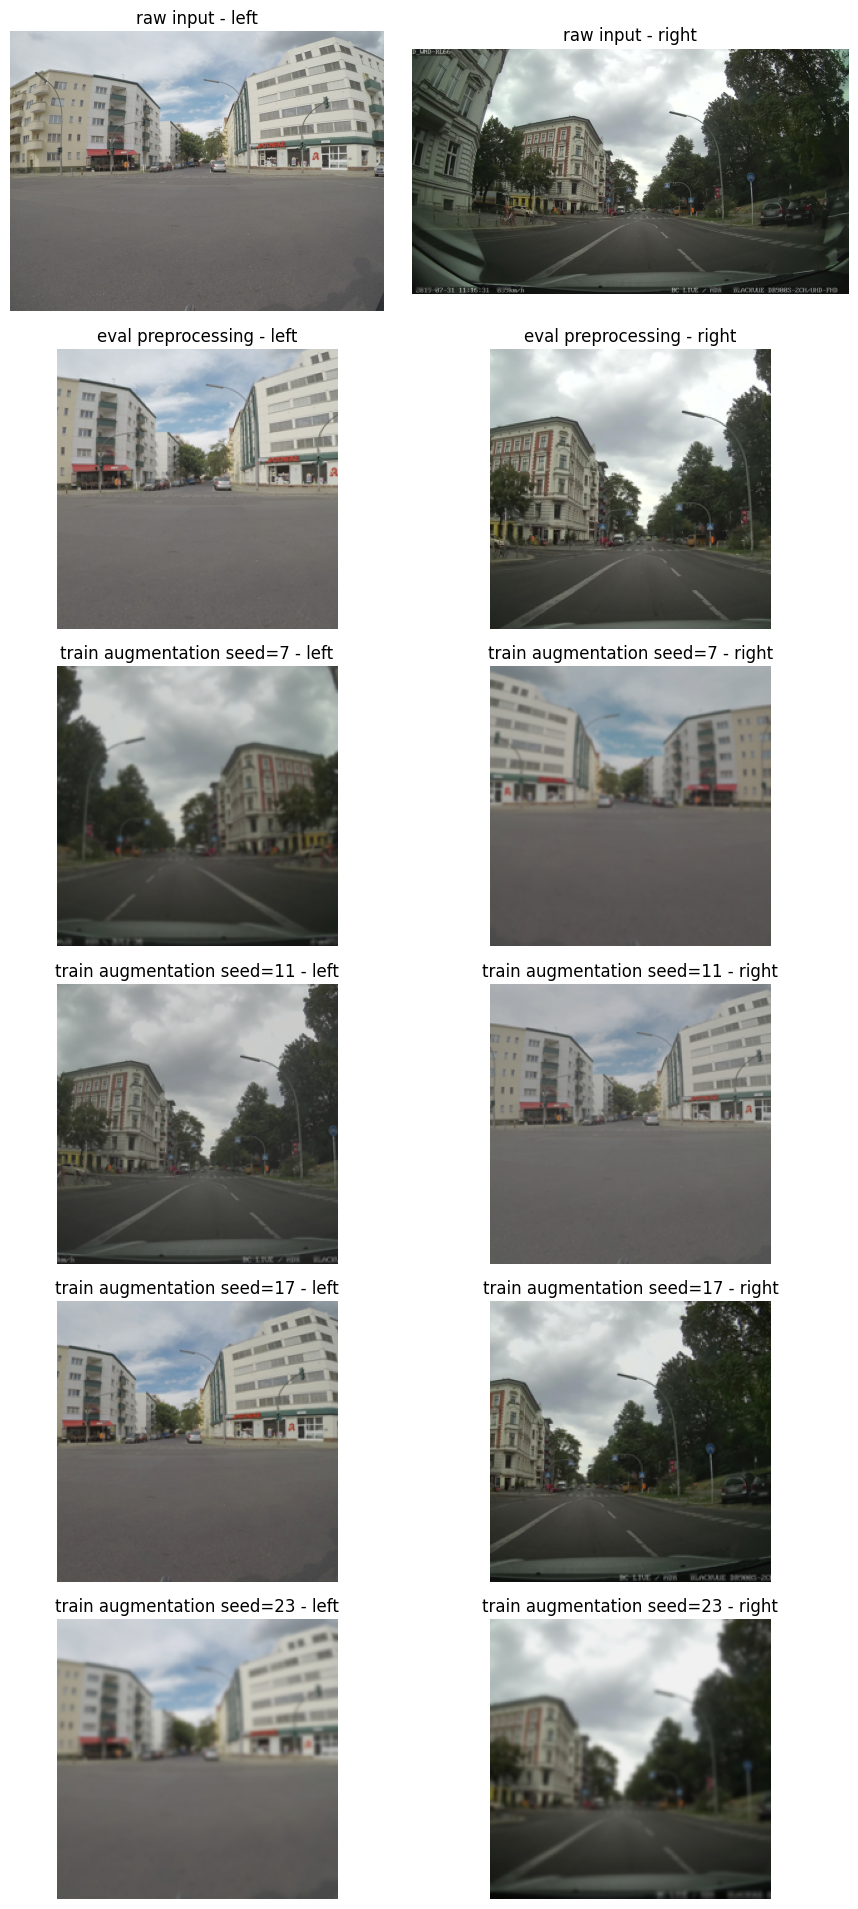

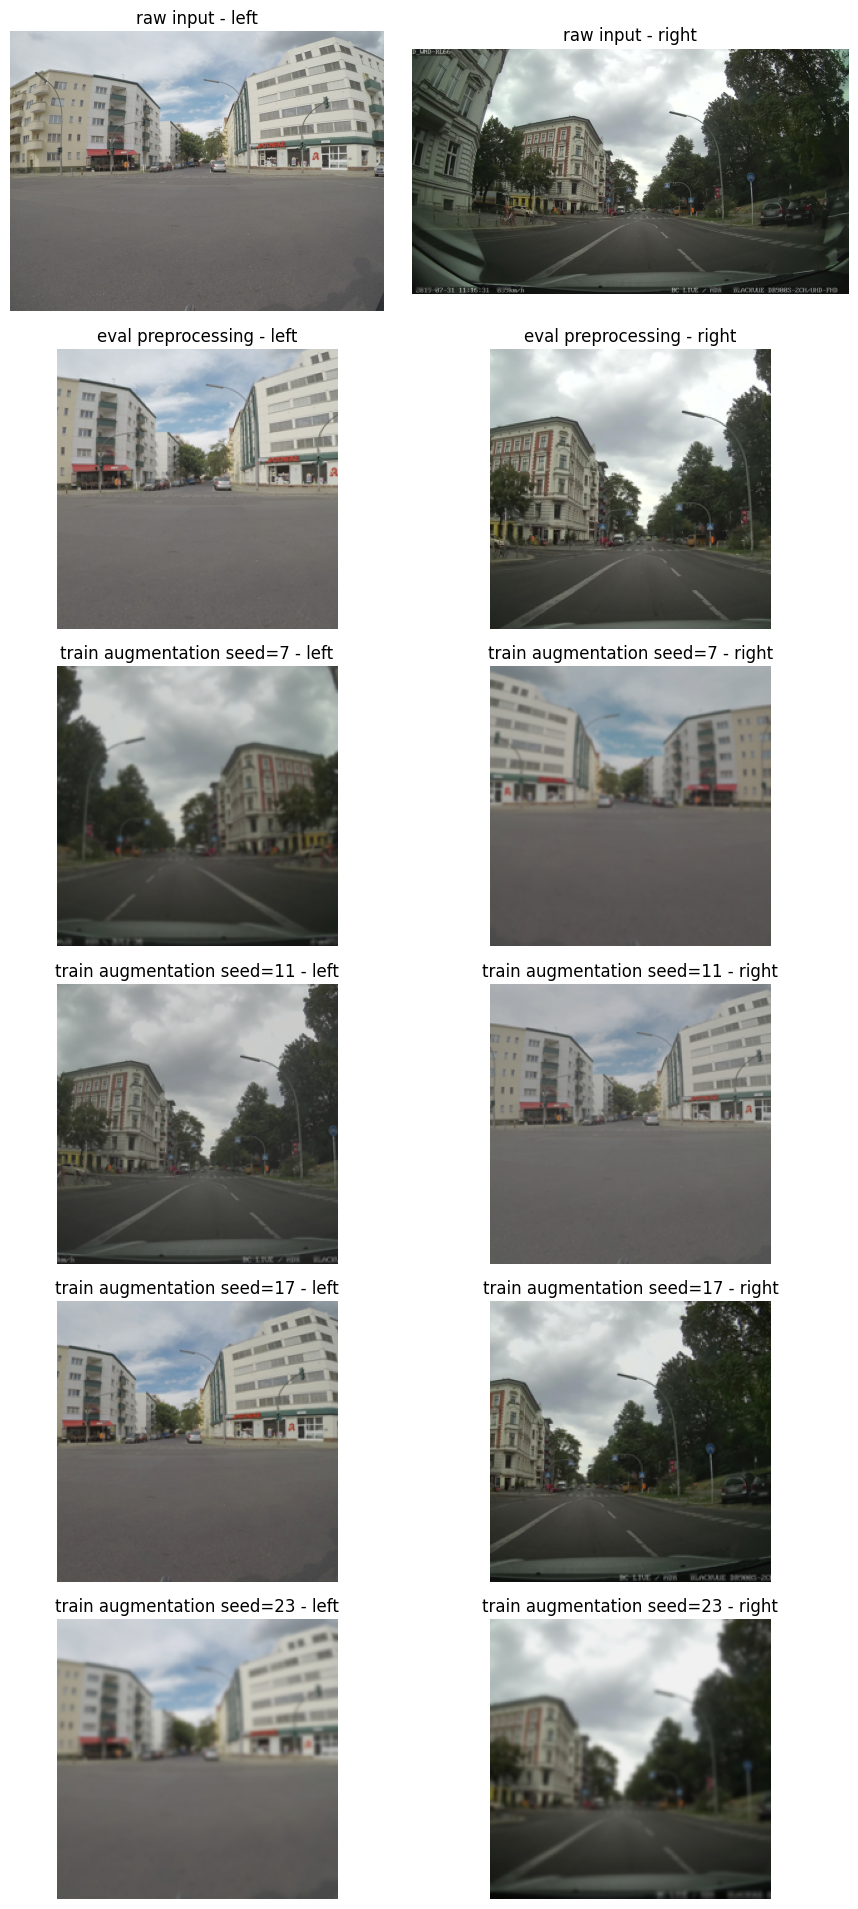

In [6]:
seeds = [7, 11, 17, 23]
eval_sample, eval_trace = transform_with_seed(eval_transform, raw_sample, seed=1)
augmented = [transform_with_seed(train_transform, raw_sample, seed=s) for s in seeds]

fig, axes = plt.subplots(2 + len(augmented), 2, figsize=(9, 3.2 * (2 + len(augmented))))
show_pair(axes[0, 0], axes[0, 1], raw_sample, "raw input")
show_pair(axes[1, 0], axes[1, 1], eval_sample, "eval preprocessing")

for row_idx, (seed, (sample, trace)) in enumerate(zip(seeds, augmented), start=2):
    label = f"train augmentation seed={seed}"
    show_pair(axes[row_idx, 0], axes[row_idx, 1], sample, label)

fig.tight_layout()
fig

## What Was Sampled?

In [7]:
trace_rows = [{"view": "eval", "seed": 1, **eval_trace}]
for seed, (_, trace) in zip(seeds, augmented):
    trace_rows.append({"view": "train", "seed": seed, **trace})

trace_df = pd.json_normalize(trace_rows)
display(trace_df.T)

,0,1,2,3,4
view,eval,train,train,train,train
seed,1,7,11,17,23
phase,eval,train,train,train,train
augment_level,none,heavy,heavy,heavy,heavy
enable_gaze,False,False,False,False,False
gaze_output,align,align,align,align,align
resize_short,256,256,256,256,256
out_size,224,224,224,224,224
swap,False,True,True,False,False
resized_size_l,"(341, 256)","(455, 256)","(455, 256)","(341, 256)","(341, 256)"


## Save A Thesis Figure

In [8]:
output_path = ROOT / "Analysis" / "images" / "preprocessing_augmentation_examples.png"
output_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output_path, dpi=200, bbox_inches="tight")
output_path

PosixPath('/home/csantiago/Analysis/images/preprocessing_augmentation_examples.png')